
Menampilkan EDA dan Plot Dekomposisi Time Series...


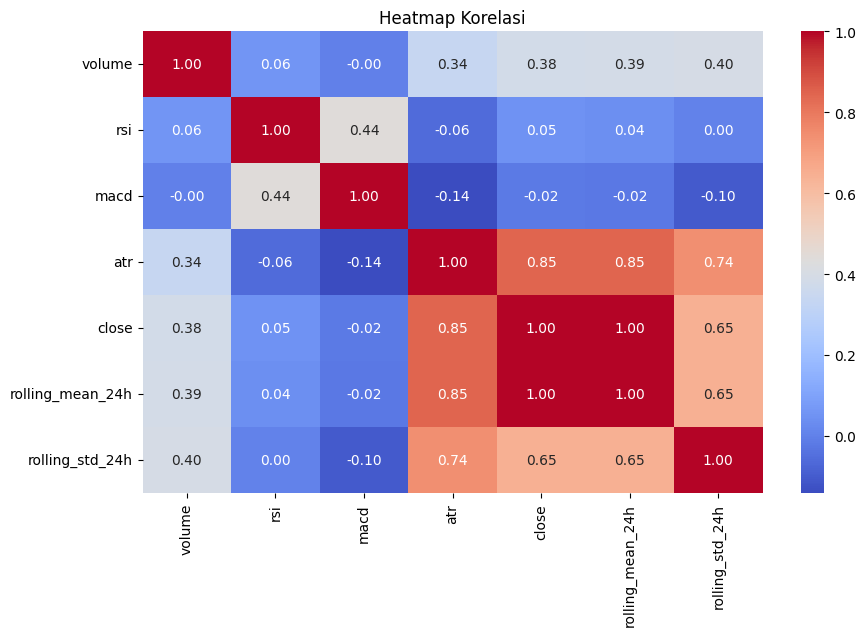

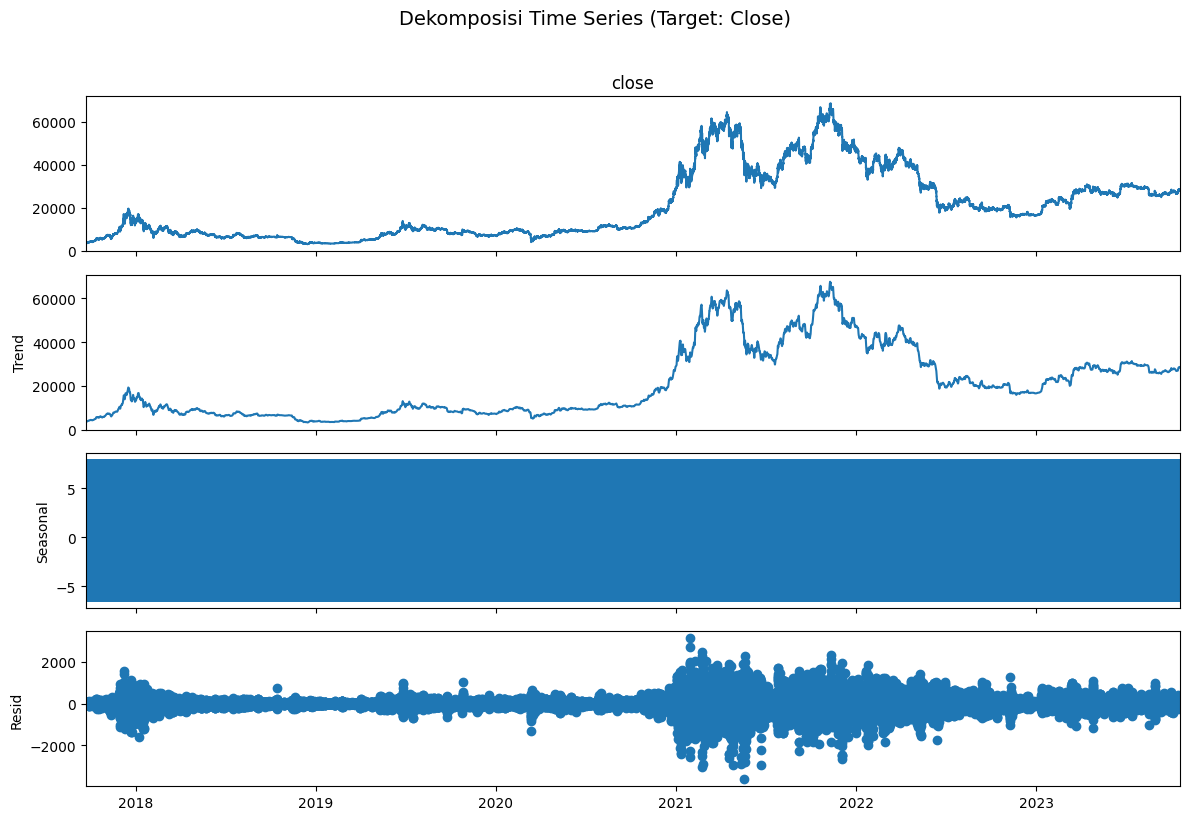


Membangun Model Baseline (dengan Custom MHA)...


Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 72, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 72, 64)    │     18,432 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 64)  │     16,640 │ lstm_3[0][0],     │
│ (CustomMultiHeadAt… │                   │            │ lstm_3[0][0],     │
│                     │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ custom_multi_hea… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_2      │ (None, 24)        │      1,560 │ global_average_p… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 36,632 (143.09 KB)

 Trainable params: 36,632 (143.09 KB)

 Non-trainable params: 0 (0.00 B)


Melatih Model Baseline...
Epoch 1/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0023 - val_loss: 0.0718
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0043 - val_loss: 0.0882
Epoch 3/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0054 - val_loss: 0.1122
Epoch 4/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0057 - val_loss: 0.0924
Epoch 5/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0055 - val_loss: 0.0779
✅ Model Baseline Disimpan: model_baseline_LSTM.keras

Melakukan Evaluasi Test Data pada Model BASELINE...
🌟 MAE Baseline (Scaled): 0.24732


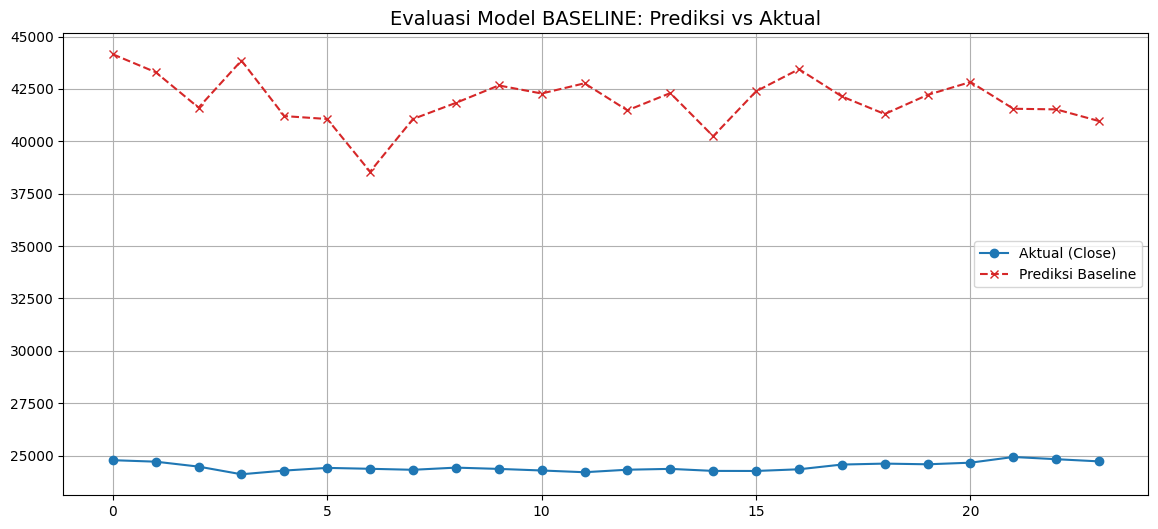


Tabel Perbandingan BASELINE:


,Jam ke,Aktual,Prediksi Baseline
0,1,24777.01,44153.696837
1,2,24706.61,43298.055506
2,3,24471.01,41606.484829
3,4,24104.69,43853.475368
4,5,24281.86,41203.173432
5,6,24409.25,41064.424791
6,7,24366.71,38548.524871
7,8,24318.56,41063.757580
8,9,24422.31,41834.280756
9,10,24361.12,42665.633270


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import time
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)
date_col = [col for col in df.columns if 'date' in col.lower()][0]
df[date_col] = pd.to_datetime(df[date_col], format='mixed')
df.set_index(date_col, inplace=True)
df.columns = df.columns.str.lower()

features = ['volume usdt', 'rsi', 'macd_hist', 'atr', 'close']
df = df[features]
df.columns = ['volume', 'rsi', 'macd', 'atr', 'close']

df['rolling_mean_24h'] = df['close'].rolling(window=24).mean()
df['rolling_std_24h'] = df['close'].rolling(window=24).std()
df.dropna(inplace=True)

n = len(df)
train_df, val_df, test_df = df[0:int(n*0.7)], df[int(n*0.7):int(n*0.9)], df[int(n*0.9):]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

window_size, horizon = 72, 24
target_idx = df.columns.get_loc('close')
num_features = train_scaled.shape[1]

def create_sequences(data):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[(i + window_size):(i + window_size + horizon), target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("\nMenampilkan EDA dan Plot Dekomposisi Time Series...")
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi')
plt.show()

decompose_result = seasonal_decompose(df['close'], model='additive', period=24)
fig = decompose_result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Time Series (Target: Close)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

@tf.keras.utils.register_keras_serializable()
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads, self.key_dim = num_heads, key_dim
        self.wq = tf.keras.layers.Dense(num_heads * key_dim)
        self.wk = tf.keras.layers.Dense(num_heads * key_dim)
        self.wv = tf.keras.layers.Dense(num_heads * key_dim)
        self.dense = tf.keras.layers.Dense(num_heads * key_dim)
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    def call(self, v, k, q):
        batch_size = tf.shape(q)[0]
        q, k, v = self.split_heads(self.wq(q), batch_size), self.split_heads(self.wk(k), batch_size), self.split_heads(self.wv(v), batch_size)
        attention_weights = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(tf.shape(k)[-1], tf.float32)), axis=-1)
        return self.dense(tf.reshape(tf.transpose(tf.matmul(attention_weights, v), perm=[0, 2, 1, 3]), (batch_size, -1, self.num_heads * self.key_dim)))
    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

@tf.keras.utils.register_keras_serializable()
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)
    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b
    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

print("\nMembangun Model Baseline (dengan Custom MHA)...")
inputs = tf.keras.layers.Input(shape=(window_size, num_features))
x = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)

x = CustomMultiHeadAttention(num_heads=2, key_dim=32)(v=x, k=x, q=x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = CustomDense(horizon)(x)

model_baseline = tf.keras.Model(inputs, outputs, name="baseline_lstm")
model_baseline.summary()

print("\nMelatih Model Baseline...")
model_baseline.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model_baseline.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

model_baseline.save('model_baseline_LSTM.keras')
print("✅ Model Baseline Disimpan: model_baseline_LSTM.keras")

print("\nMelakukan Evaluasi Test Data pada Model BASELINE...")
y_pred_base = model_baseline.predict(X_test, verbose=0)
mae_base = np.mean(np.abs(y_test - y_pred_base))
print(f"🌟 MAE Baseline (Scaled): {mae_base:.5f}")

dummy_pred_base = np.zeros((len(y_pred_base), horizon, num_features))
dummy_test_base = np.zeros((len(y_test), horizon, num_features))
for i in range(horizon):
    dummy_pred_base[:, i, target_idx] = y_pred_base[:, i]
    dummy_test_base[:, i, target_idx] = y_test[:, i]

y_pred_inv_base = scaler.inverse_transform(dummy_pred_base.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)
y_test_inv_base = scaler.inverse_transform(dummy_test_base.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)

sample_idx = 0
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv_base[sample_idx], marker='o', label='Aktual (Close)', color='tab:blue')
plt.plot(y_pred_inv_base[sample_idx], marker='x', linestyle='--', label='Prediksi Baseline', color='tab:red')
plt.title('Evaluasi Model BASELINE: Prediksi vs Aktual', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

df_base = pd.DataFrame({'Jam ke': np.arange(1, horizon + 1), 'Aktual': y_test_inv_base[sample_idx], 'Prediksi Baseline': y_pred_inv_base[sample_idx]})
print("\nTabel Perbandingan BASELINE:")
display(df_base)

In [7]:
tf.random.set_seed(42)
np.random.seed(42)

@tf.keras.utils.register_keras_serializable()
class CustomLeakyReLU(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.alpha = float(alpha)
    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)
    def get_config(self):
        config = super().get_config()
        config.update({"alpha": self.alpha})
        return config

@tf.keras.utils.register_keras_serializable()
class Seq2SeqLSTM(tf.keras.Model):
    def __init__(self, units, out_steps, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.out_steps = out_steps
        self.encoder = tf.keras.layers.LSTM(units, return_state=True, return_sequences=True)
        self.decoder = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.mha = CustomMultiHeadAttention(num_heads=2, key_dim=32)
        self.custom_activation = CustomLeakyReLU()
        self.custom_dense = CustomDense(1)

    def call(self, inputs, training=False, targets=None):
        enc_output, state_h, state_c = self.encoder(inputs)
        states = [state_h, state_c]
        dec_input = tf.expand_dims(inputs[:, -1, 4:5], 1)
        outputs_array = tf.TensorArray(tf.float32, size=self.out_steps)

        for i in range(self.out_steps):
            dec_out, state_h, state_c = self.decoder(dec_input, initial_state=states)
            states = [state_h, state_c]
            context = self.mha(enc_output, enc_output, dec_out)
            combined = self.custom_activation(tf.concat([dec_out, context], axis=-1))
            pred = self.custom_dense(combined)
            outputs_array = outputs_array.write(i, pred[:, 0, :])

            if training and targets is not None:
                dec_input = tf.expand_dims(targets[:, i:i+1], 1)
            else:
                dec_input = pred

        return tf.transpose(outputs_array.stack(), [1, 0, 2])[:, :, 0]

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "out_steps": self.out_steps})
        return config

advanced_model = Seq2SeqLSTM(units=128, out_steps=horizon)
_ = advanced_model(tf.zeros((1, window_size, num_features)))
advanced_model.summary()
print("✅ Cetak Biru Seq2Seq Selesai.")

Model: "seq2_seq_lstm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ ((1, 72, 128), (1,     │        69,632 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ((1, 1, 128), (1,      │        66,560 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention_2   │ ?                      │        28,928 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_leaky_re_lu_1            │ ?                      │             0 │
│ (CustomLeakyReLU)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_3 (CustomDense)    │ ?                      │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,313 (645.75 KB)

 Trainable params: 165,313 (645.75 KB)

 Non-trainable params: 0 (0.00 B)

✅ Cetak Biru Seq2Seq Selesai.


▶️ MEMULAI PHASE 1: TRAINING AWAL...
Epoch 01/50 - Loss: 0.00406 - Val Loss: 0.15046
Epoch 02/50 - Loss: 0.00476 - Val Loss: 0.10128
Epoch 03/50 - Loss: 0.00421 - Val Loss: 0.06339
Epoch 04/50 - Loss: 0.00403 - Val Loss: 0.10068
Epoch 05/50 - Loss: 0.00451 - Val Loss: 0.07714
Epoch 06/50 - Loss: 0.00434 - Val Loss: 0.06630
   [-] LR turun: 0.001000 -> 0.000500
Epoch 07/50 - Loss: 0.00407 - Val Loss: 0.07226
Epoch 08/50 - Loss: 0.00406 - Val Loss: 0.06577
Epoch 09/50 - Loss: 0.00298 - Val Loss: 0.05020
Epoch 10/50 - Loss: 0.00293 - Val Loss: 0.01941
Epoch 11/50 - Loss: 0.00277 - Val Loss: 0.01374
Epoch 12/50 - Loss: 0.00279 - Val Loss: 0.01512
Epoch 13/50 - Loss: 0.00255 - Val Loss: 0.01461
Epoch 14/50 - Loss: 0.00244 - Val Loss: 0.01454
   [-] LR turun: 0.000500 -> 0.000250
Epoch 15/50 - Loss: 0.00236 - Val Loss: 0.01940
Epoch 16/50 - Loss: 0.00231 - Val Loss: 0.03386
Epoch 17/50 - Loss: 0.00206 - Val Loss: 0.01720
Epoch 18/50 - Loss: 0.00217 - Val Loss: 0.01409
   [-] LR turun: 0.0002

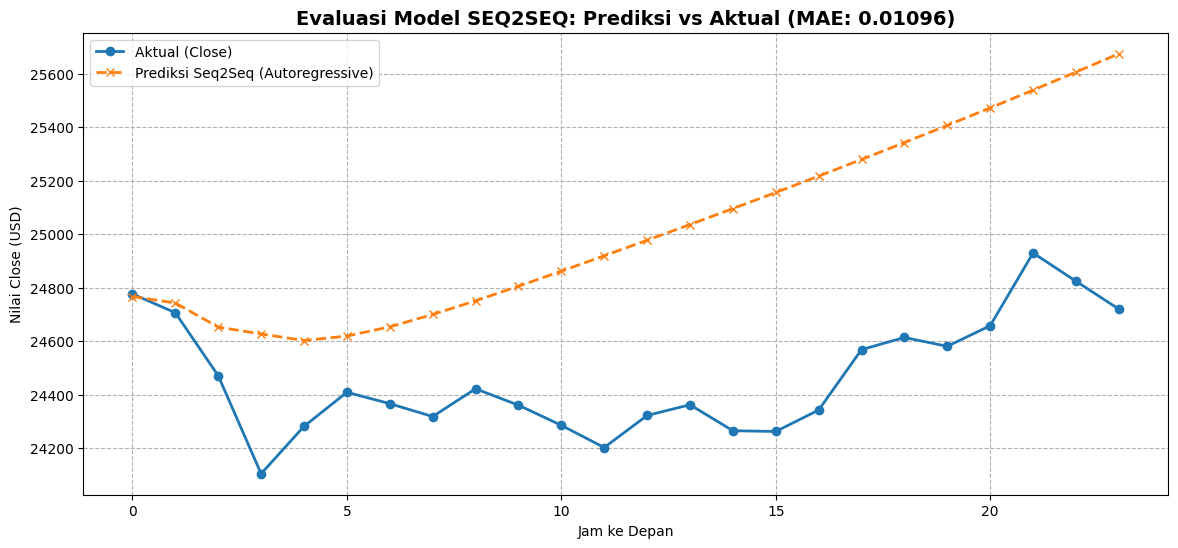


Tabel Perbandingan SEQ2SEQ (Autoregressive):


,Jam ke,Aktual (USD),Prediksi Seq2Seq (USD)
0,1,24777.01,24767.232223
1,2,24706.61,24743.134596
2,3,24471.01,24652.891403
3,4,24104.69,24627.398876
4,5,24281.86,24602.836933
5,6,24409.25,24619.517205
6,7,24366.71,24654.071703
7,8,24318.56,24700.159975
8,9,24422.31,24751.340119
9,10,24361.12,24805.844612


In [ ]:
class AdvancedWeightedLoss(tf.keras.losses.Loss):
    def __init__(self, horizon, **kwargs):
        super().__init__(**kwargs)
        self.weights = tf.constant([1.0 + (i * 0.005) for i in range(horizon)], dtype=tf.float32)
    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred) * self.weights)

class UltimateTrainingCallback:
    def __init__(self, model, patience_lr=4, patience_stop=12, factor=0.5, min_lr=1e-6):
        self.model, self.patience_lr, self.patience_stop = model, patience_lr, patience_stop
        self.factor, self.min_lr = factor, min_lr
        self.best_val_loss, self.best_weights = float('inf'), None
        self.wait_lr, self.wait_stop, self.stop_training = 0, 0, False

    def on_epoch_end(self, epoch, val_loss, optimizer):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()
            self.wait_lr, self.wait_stop = 0, 0
        else:
            self.wait_lr += 1; self.wait_stop += 1
            if self.wait_lr >= self.patience_lr:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                optimizer.learning_rate.assign(new_lr)
                print(f"   [-] LR turun: {old_lr:.6f} -> {new_lr:.6f}")
                self.wait_lr = 0
            if self.wait_stop >= self.patience_stop:
                print(f"   [!] Early Stopping dipicu di epoch {epoch+1}")
                self.stop_training = True

class FineTuneCallback:
    def __init__(self, model, patience_lr=5, factor=0.5, min_lr=1e-7):
        self.model, self.patience_lr, self.factor, self.min_lr = model, patience_lr, factor, min_lr
        self.best_val_loss, self.best_weights, self.wait_lr = float('inf'), None, 0
    def on_epoch_end(self, epoch, val_loss, optimizer):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()
            self.wait_lr = 0
        else:
            self.wait_lr += 1
            if self.wait_lr >= self.patience_lr:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                optimizer.learning_rate.assign(new_lr)
                print(f"   [-] Bergerak terlalu cepat. LR diperkecil: {old_lr:.7f} -> {new_lr:.7f}")
                self.wait_lr = 0

loss_fn = AdvancedWeightedLoss(horizon=horizon)
train_loss_metric = tf.keras.metrics.Mean()
val_loss_metric = tf.keras.metrics.Mean()

optimizer_base = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
optimizer_ft = tf.keras.optimizers.Adam(learning_rate=0.00005, clipnorm=1.0)

@tf.function
def train_step_base(x, y):
    with tf.GradientTape() as tape:
        predictions = advanced_model(x, training=True, targets=y)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, advanced_model.trainable_variables)
    optimizer_base.apply_gradients(zip(gradients, advanced_model.trainable_variables))
    train_loss_metric(loss)

@tf.function
def train_step_ft(x, y):
    with tf.GradientTape() as tape:
        predictions = advanced_model(x, training=True, targets=y)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, advanced_model.trainable_variables)
    optimizer_ft.apply_gradients(zip(gradients, advanced_model.trainable_variables))
    train_loss_metric(loss)

@tf.function
def val_step(x, y):
    val_loss_metric(loss_fn(y, advanced_model(x, training=False)))

print("▶️ MEMULAI PHASE 1: TRAINING AWAL...")
callback_base = UltimateTrainingCallback(model=advanced_model)

for epoch in range(50):
    train_loss_metric.reset_state(); val_loss_metric.reset_state()
    for x_batch, y_batch in train_ds: train_step_base(x_batch, y_batch)
    for x_batch_val, y_batch_val in val_ds: val_step(x_batch_val, y_batch_val)
    train_loss, val_loss = train_loss_metric.result(), val_loss_metric.result()
    callback_base.on_epoch_end(epoch, val_loss, optimizer_base)
    print(f"Epoch {epoch + 1:02d}/50 - Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f}")
    if callback_base.stop_training: break

if callback_base.best_weights is not None:
    advanced_model.set_weights(callback_base.best_weights)

print("\n▶️ MEMULAI PHASE 2: FINE-TUNING (Perasan Terakhir)...")
callback_ft = FineTuneCallback(model=advanced_model)

for epoch in range(30):
    train_loss_metric.reset_state(); val_loss_metric.reset_state()
    for x_batch, y_batch in train_ds: train_step_ft(x_batch, y_batch)
    for x_batch_val, y_batch_val in val_ds: val_step(x_batch_val, y_batch_val)
    train_loss, val_loss = train_loss_metric.result(), val_loss_metric.result()
    callback_ft.on_epoch_end(epoch, val_loss, optimizer_ft)
    print(f"Fine-Tune Epoch {epoch + 1:02d}/30 - Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f}")

if callback_ft.best_weights is not None:
    advanced_model.set_weights(callback_ft.best_weights)

advanced_model.save('model_seq2seq_LSTM.keras')
advanced_model.save('best_model_seq2seq_LSTM.keras')
print("\n✅ File Model 'model_seq2seq_LSTM.keras' dan 'best_model_seq2seq_LSTM.keras' BERHASIL DIAMANKAN!")

print("\nMelakukan Evaluasi Test Data menggunakan INFERENSI AUTOREGRESSIVE...")
y_pred_list, y_test_list = [], []
for x_batch, y_batch in test_ds:
    y_pred_list.append(advanced_model(x_batch, training=False))
    y_test_list.append(y_batch)

y_pred_scaled = tf.concat(y_pred_list, axis=0).numpy()
y_test_scaled = tf.concat(y_test_list, axis=0).numpy()

mae_scaled = np.mean(np.abs(y_test_scaled - y_pred_scaled))
print(f"\n🌟 MAE Akhir SEQ2SEQ (Kondisi Scaled): {mae_scaled:.5f}")

dummy_pred = np.zeros((len(y_pred_scaled), horizon, num_features))
dummy_test = np.zeros((len(y_test_scaled), horizon, num_features))
for i in range(horizon):
    dummy_pred[:, i, target_idx] = y_pred_scaled[:, i]
    dummy_test[:, i, target_idx] = y_test_scaled[:, i]

y_pred_inv = scaler.inverse_transform(dummy_pred.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)
y_test_inv = scaler.inverse_transform(dummy_test.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)

plt.figure(figsize=(14, 6))
plt.plot(y_test_inv[0], marker='o', label='Aktual (Close)', color='tab:blue', linewidth=2)
plt.plot(y_pred_inv[0], marker='x', linestyle='--', label='Prediksi Seq2Seq (Autoregressive)', color='tab:orange', linewidth=2)
plt.title(f'Evaluasi Model SEQ2SEQ: Prediksi vs Aktual (MAE: {mae_scaled:.5f})', fontsize=14, fontweight='bold')
plt.xlabel('Jam ke Depan')
plt.ylabel('Nilai Close (USD)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

df_result = pd.DataFrame({'Jam ke': np.arange(1, horizon + 1), 'Aktual (USD)': y_test_inv[0], 'Prediksi Seq2Seq (USD)': y_pred_inv[0]})
print("\nTabel Perbandingan SEQ2SEQ (Autoregressive):")
display(df_result)

✅ Otak Model 0.01096 berhasil disuntikkan tanpa training ulang!
✅ File 'model_seq2seq_LSTM.keras' siap di-download!

Melakukan Evaluasi Test Data menggunakan INFERENSI AUTOREGRESSIVE...

🌟 MAE Akhir SEQ2SEQ (Kondisi Scaled): 0.01096


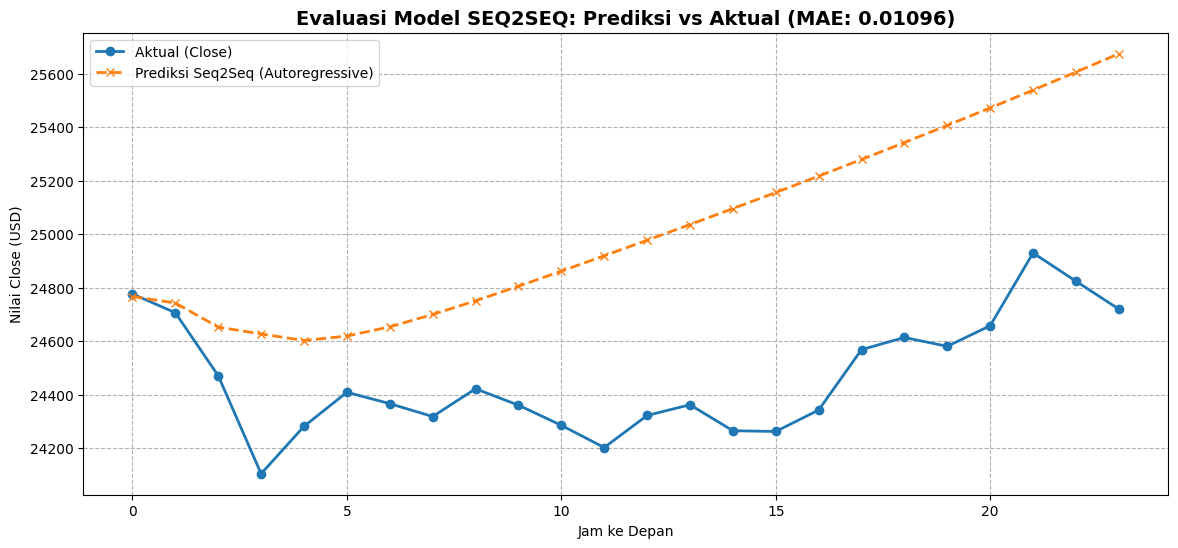


Tabel Perbandingan SEQ2SEQ (Autoregressive):


,Jam ke,Aktual (USD),Prediksi Seq2Seq (USD)
0,1,24777.01,24767.232223
1,2,24706.61,24743.134596
2,3,24471.01,24652.891403
3,4,24104.69,24627.398876
4,5,24281.86,24602.836933
5,6,24409.25,24619.517205
6,7,24366.71,24654.071703
7,8,24318.56,24700.159975
8,9,24422.31,24751.340119
9,10,24361.12,24805.844612


In [8]:
try:
    advanced_model.load_weights('best_model_seq2seq_LSTM.keras')
    print("✅ Otak Model 0.01096 berhasil disuntikkan tanpa training ulang!")
except Exception as e:
    print("❌ ERROR: Pastikan kamu sudah upload file 'best_model_seq2seq_LSTM.keras' ke Colab!")
    raise e

advanced_model.save('model_seq2seq_LSTM.keras')
print("✅ File 'model_seq2seq_LSTM.keras' siap di-download!")

print("\nMelakukan Evaluasi Test Data menggunakan INFERENSI AUTOREGRESSIVE...")
y_pred_list, y_test_list = [], []
for x_batch, y_batch in test_ds:
    y_pred_list.append(advanced_model(x_batch, training=False))
    y_test_list.append(y_batch)

y_pred_scaled = tf.concat(y_pred_list, axis=0).numpy()
y_test_scaled = tf.concat(y_test_list, axis=0).numpy()

mae_scaled = np.mean(np.abs(y_test_scaled - y_pred_scaled))
print(f"\n🌟 MAE Akhir SEQ2SEQ (Kondisi Scaled): {mae_scaled:.5f}")

dummy_pred = np.zeros((len(y_pred_scaled), horizon, num_features))
dummy_test = np.zeros((len(y_test_scaled), horizon, num_features))
for i in range(horizon):
    dummy_pred[:, i, target_idx] = y_pred_scaled[:, i]
    dummy_test[:, i, target_idx] = y_test_scaled[:, i]

y_pred_inv = scaler.inverse_transform(dummy_pred.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)
y_test_inv = scaler.inverse_transform(dummy_test.reshape(-1, num_features))[:, target_idx].reshape(-1, horizon)

plt.figure(figsize=(14, 6))
plt.plot(y_test_inv[0], marker='o', label='Aktual (Close)', color='tab:blue', linewidth=2)
plt.plot(y_pred_inv[0], marker='x', linestyle='--', label='Prediksi Seq2Seq (Autoregressive)', color='tab:orange', linewidth=2)
plt.title(f'Evaluasi Model SEQ2SEQ: Prediksi vs Aktual (MAE: {mae_scaled:.5f})', fontsize=14, fontweight='bold')
plt.xlabel('Jam ke Depan')
plt.ylabel('Nilai Close (USD)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

df_result = pd.DataFrame({'Jam ke': np.arange(1, horizon + 1), 'Aktual (USD)': y_test_inv[0], 'Prediksi Seq2Seq (USD)': y_pred_inv[0]})
print("\nTabel Perbandingan SEQ2SEQ (Autoregressive):")
display(df_result)

In [ ]:
!pip freeze > requirements.txt